In [4]:
import matplotlib.pyplot as plt

# =========================
# 全局绘图风格设置（适合中文论文图）
# =========================
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

# 全局字号设置
plt.rcParams["font.size"] = 13              # 基础字号
plt.rcParams["axes.titlesize"] = 18         # 标题字号
plt.rcParams["axes.labelsize"] = 15         # 坐标轴标题字号
plt.rcParams["xtick.labelsize"] = 13        # x轴刻度字号
plt.rcParams["ytick.labelsize"] = 13        # y轴刻度字号
plt.rcParams["legend.fontsize"] = 13        # 图例字号

# 线条和刻度美化
plt.rcParams["axes.linewidth"] = 1.1
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

## 异常值处理

原始数据维度： (2169, 4)
字段名： ['订单编号', '重量', '体积', '目标客户编号']

========== 原始缺失值统计 ==========
订单总数：2169
重量缺失数量：14
体积缺失数量：16
重量和体积同时缺失数量：0
重量缺失比例：0.6455%
体积缺失比例：0.7377%

========== 原始重量-体积相关性 ==========
原始完整样本数量：2139
原始 Pearson 相关系数：0.966676


C:\Users\86198\AppData\Local\Temp\ipykernel_28976\110108686.py:92: UserWarning: Glyph 179 (\N{SUPERSCRIPT THREE}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\86198\AppData\Local\Temp\ipykernel_28976\110108686.py:94: UserWarning: Glyph 179 (\N{SUPERSCRIPT THREE}) missing from font(s) SimHei.
  plt.savefig(raw_scatter_path, dpi=300)
d:\Anaconda3\envs\tensorflow\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 179 (\N{SUPERSCRIPT THREE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


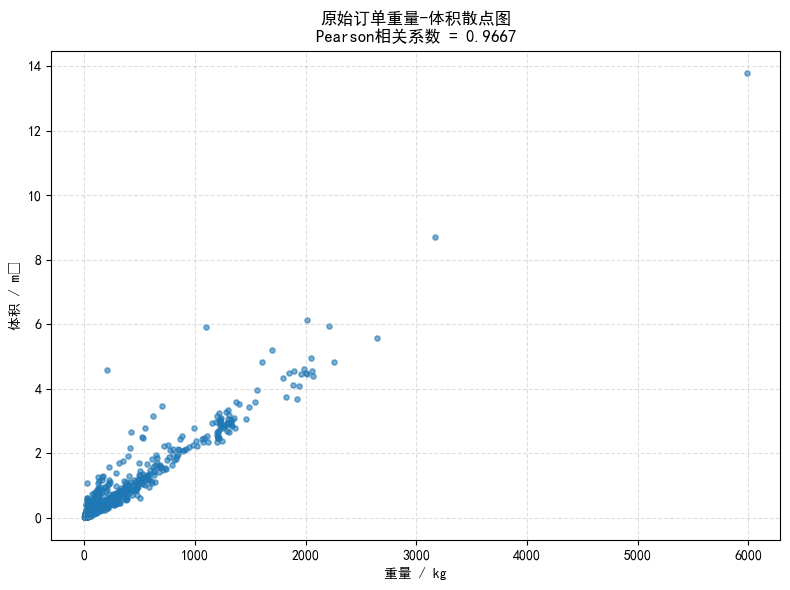

原始散点图已保存至： 处理结果\原始订单_重量体积散点图.png

========== 超载异常订单 ==========
最大单车载重：3000 kg
超载异常订单数量：2


,订单编号,重量,体积,目标客户编号
345,1686,5987.0501,13.79751,31
1122,1287,3165.6900,8.70067,55



========== 剔除异常订单后 ==========
剔除前订单数量： 2169
剔除后订单数量： 2167
剔除订单数量： 2
剔除异常订单后的订单信息已保存至： 处理结果\订单信息_剔除异常订单后.xlsx


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
order_path = r"附件\订单信息.xlsx"
output_dir = r"处理结果"
os.makedirs(output_dir, exist_ok=True)

raw_scatter_path = os.path.join(output_dir, "原始订单_重量体积散点图.png")
cleaned_order_path = os.path.join(output_dir, "订单信息_剔除异常订单后.xlsx")

# =========================
# 2. 读取订单信息
# =========================
order_df = pd.read_excel(order_path)
order_df.columns = order_df.columns.astype(str).str.strip()

print("原始数据维度：", order_df.shape)
print("字段名：", list(order_df.columns))

# =========================
# 3. 字段设置
# =========================
order_col = "订单编号"
weight_col = "重量"
volume_col = "体积"
customer_col = "目标客户编号"

required_cols = [order_col, weight_col, volume_col, customer_col]

for col in required_cols:
    if col not in order_df.columns:
        raise ValueError(f"缺少必要字段：{col}，请检查 Excel 表头是否一致。")

# 转换为数值型
order_df[weight_col] = pd.to_numeric(order_df[weight_col], errors="coerce")
order_df[volume_col] = pd.to_numeric(order_df[volume_col], errors="coerce")

# =========================
# 4. 缺失值初步统计
# =========================
total_orders = len(order_df)
missing_weight = order_df[weight_col].isna().sum()
missing_volume = order_df[volume_col].isna().sum()
missing_both = (order_df[weight_col].isna() & order_df[volume_col].isna()).sum()

print("\n========== 原始缺失值统计 ==========")
print(f"订单总数：{total_orders}")
print(f"重量缺失数量：{missing_weight}")
print(f"体积缺失数量：{missing_volume}")
print(f"重量和体积同时缺失数量：{missing_both}")
print(f"重量缺失比例：{missing_weight / total_orders * 100:.4f}%")
print(f"体积缺失比例：{missing_volume / total_orders * 100:.4f}%")

# =========================
# 5. 提取完整样本，用于原始散点图
# =========================
raw_complete_df = order_df.dropna(subset=[weight_col, volume_col]).copy()
raw_complete_df = raw_complete_df[
    (raw_complete_df[weight_col] >= 0) &
    (raw_complete_df[volume_col] >= 0)
].copy()

raw_corr = raw_complete_df[[weight_col, volume_col]].corr(method="pearson").iloc[0, 1]

print("\n========== 原始重量-体积相关性 ==========")
print(f"原始完整样本数量：{len(raw_complete_df)}")
print(f"原始 Pearson 相关系数：{raw_corr:.6f}")

# =========================
# 6. 绘制原始重量-体积散点图
# =========================
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 6))
plt.scatter(
    raw_complete_df[weight_col],
    raw_complete_df[volume_col],
    s=14,
    alpha=0.60
)

plt.xlabel("重量 / kg")
plt.ylabel("体积 / m³")
plt.title(f"原始订单重量-体积散点图\nPearson相关系数 = {raw_corr:.4f}")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig(raw_scatter_path, dpi=300)
plt.show()

print("原始散点图已保存至：", raw_scatter_path)

# =========================
# 7. 超载异常订单识别
# =========================
Q_max = 3000

overload_mask = order_df[weight_col] > Q_max
overload_orders = order_df.loc[
    overload_mask,
    [order_col, weight_col, volume_col, customer_col]
].copy()

print("\n========== 超载异常订单 ==========")
print(f"最大单车载重：{Q_max} kg")
print(f"超载异常订单数量：{len(overload_orders)}")
display(overload_orders)

# =========================
# 8. 剔除超载异常订单
# =========================
order_clean_df = order_df.loc[~overload_mask].copy()

print("\n========== 剔除异常订单后 ==========")
print("剔除前订单数量：", len(order_df))
print("剔除后订单数量：", len(order_clean_df))
print("剔除订单数量：", len(order_df) - len(order_clean_df))

order_clean_df.to_excel(cleaned_order_path, index=False)
print("剔除异常订单后的订单信息已保存至：", cleaned_order_path)

## 缺失值处理

========== 剔除异常后缺失值统计 ==========
订单总数：2167
重量缺失数量：14
体积缺失数量：16
重量和体积同时缺失数量：0
重量缺失比例：0.6461%
体积缺失比例：0.7383%

========== 剔除异常后的重量-体积相关性 ==========
完整样本数量： 2137
Pearson 相关系数：0.959808


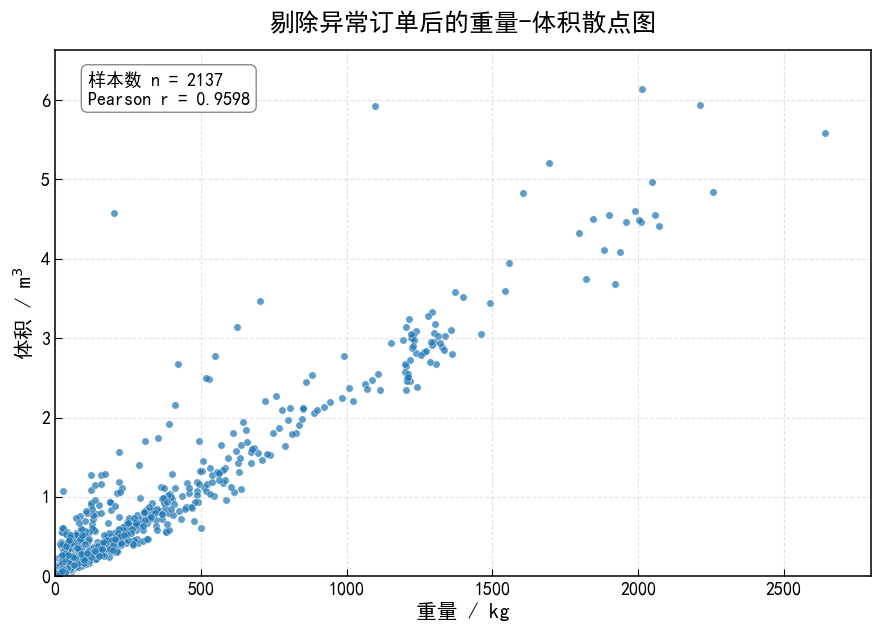

剔除异常后的散点图已保存至： 处理结果\剔除异常后_重量体积散点图.png

========== 模型一：用重量预测体积 ==========
回归方程：体积 = 0.00233305 × 重量 + 0.05197989
R²：0.921232
MAE：0.095030
RMSE：0.203001


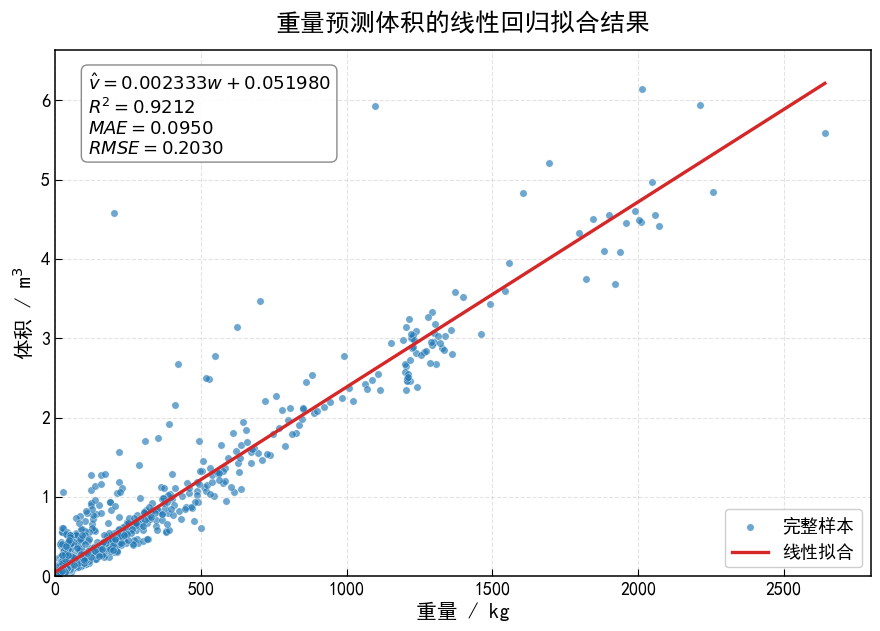

重量预测体积拟合图已保存至： 处理结果\剔除异常后_重量预测体积_拟合图.png

========== 模型二：用体积预测重量 ==========
回归方程：重量 = 394.86164050 × 体积 + -10.47579380
R²：0.921232
MAE：37.495292
RMSE：83.514026


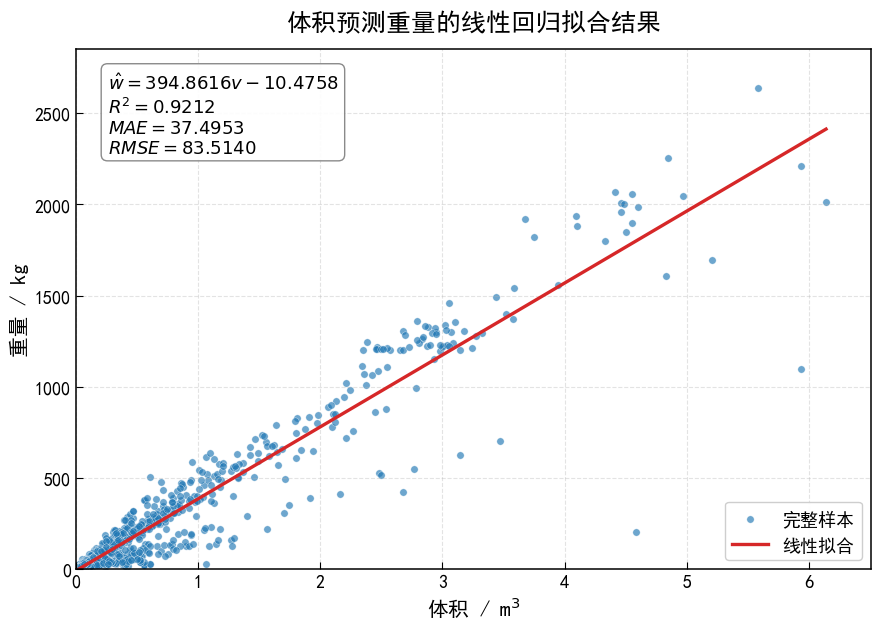

体积预测重量拟合图已保存至： 处理结果\剔除异常后_体积预测重量_拟合图.png

========== 被填补的订单记录 ==========


,订单编号,重量,体积,目标客户编号
8,61,36.800000,0.137836,4
80,75,97.835000,0.280234,7
151,143,52.702069,0.160000,8
206,194,13.452822,0.060600,9
215,260,29.444718,0.101100,9
285,223,47.672000,0.163201,12
485,683,33.789200,0.130812,41
522,883,15.735122,0.066380,42
526,1539,127.674000,0.349850,42
712,1625,8.070857,0.046970,47



========== 填补后缺失值统计 ==========
重量缺失数量： 0
体积缺失数量： 0

========== 填补后数值范围 ==========
重量最小值：0.000000
重量最大值：2640.500000
体积最小值：0.008410
体积最大值：6.138950

剔除异常并填补缺失后的订单信息已保存至： 处理结果\订单信息_剔除异常并填补缺失后.xlsx


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# =========================
# 0. 统一绘图风格设置：中文论文图
# =========================
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["font.size"] = 13
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 13

plt.rcParams["axes.linewidth"] = 1.1
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5


# =========================
# 1. 输出路径
# =========================
clean_scatter_path = os.path.join(output_dir, "剔除异常后_重量体积散点图.png")
fit_volume_path = os.path.join(output_dir, "剔除异常后_重量预测体积_拟合图.png")
fit_weight_path = os.path.join(output_dir, "剔除异常后_体积预测重量_拟合图.png")
filled_order_path = os.path.join(output_dir, "订单信息_剔除异常并填补缺失后.xlsx")


# =========================
# 2. 剔除异常后缺失值统计
# =========================
clean_total_orders = len(order_clean_df)
clean_missing_weight = order_clean_df[weight_col].isna().sum()
clean_missing_volume = order_clean_df[volume_col].isna().sum()
clean_missing_both = (
    order_clean_df[weight_col].isna() & order_clean_df[volume_col].isna()
).sum()

print("========== 剔除异常后缺失值统计 ==========")
print(f"订单总数：{clean_total_orders}")
print(f"重量缺失数量：{clean_missing_weight}")
print(f"体积缺失数量：{clean_missing_volume}")
print(f"重量和体积同时缺失数量：{clean_missing_both}")
print(f"重量缺失比例：{clean_missing_weight / clean_total_orders * 100:.4f}%")
print(f"体积缺失比例：{clean_missing_volume / clean_total_orders * 100:.4f}%")

if clean_missing_both > 0:
    raise ValueError("存在重量和体积同时缺失的订单，不能仅通过线性回归直接填补。")


# =========================
# 3. 提取剔除异常后的完整样本
# =========================
complete_df = order_clean_df.dropna(subset=[weight_col, volume_col]).copy()

complete_df = complete_df[
    (complete_df[weight_col] >= 0) &
    (complete_df[volume_col] >= 0)
].copy()

clean_corr = complete_df[[weight_col, volume_col]].corr(method="pearson").iloc[0, 1]

print("\n========== 剔除异常后的重量-体积相关性 ==========")
print("完整样本数量：", len(complete_df))
print(f"Pearson 相关系数：{clean_corr:.6f}")


# =========================
# 4. 绘制剔除异常后的散点图（论文风格）
# =========================
fig, ax = plt.subplots(figsize=(9, 6.5))

ax.scatter(
    complete_df[weight_col],
    complete_df[volume_col],
    s=28,
    alpha=0.72,
    color="#1f77b4",
    edgecolors="white",
    linewidths=0.35
)

ax.set_xlabel("重量 / kg", fontsize=15)
ax.set_ylabel("体积 / m$^3$", fontsize=15)
ax.set_title("剔除异常订单后的重量-体积散点图", fontsize=18, pad=14)

textstr = "\n".join([
    f"样本数 n = {len(complete_df)}",
    f"Pearson r = {clean_corr:.4f}"
])

ax.text(
    0.04, 0.96,
    textstr,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="gray",
        alpha=0.92
    )
)

ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
ax.tick_params(axis="both", labelsize=13)

x_min, x_max = complete_df[weight_col].min(), complete_df[weight_col].max()
y_min, y_max = complete_df[volume_col].min(), complete_df[volume_col].max()

x_pad = (x_max - x_min) * 0.06
y_pad = (y_max - y_min) * 0.08

ax.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
ax.set_ylim(max(0, y_min - y_pad), y_max + y_pad)

plt.tight_layout()
plt.savefig(clean_scatter_path, dpi=400, bbox_inches="tight")
plt.show()

print("剔除异常后的散点图已保存至：", clean_scatter_path)


# =========================
# 5. 模型一：用重量预测体积
#    v = a w + b
# =========================
X_weight = complete_df[[weight_col]].values
y_volume = complete_df[volume_col].values

model_volume = LinearRegression()
model_volume.fit(X_weight, y_volume)

volume_pred = model_volume.predict(X_weight)

a = model_volume.coef_[0]
b = model_volume.intercept_

r2_volume = r2_score(y_volume, volume_pred)
mae_volume = mean_absolute_error(y_volume, volume_pred)
rmse_volume = np.sqrt(mean_squared_error(y_volume, volume_pred))

print("\n========== 模型一：用重量预测体积 ==========")
print(f"回归方程：体积 = {a:.8f} × 重量 + {b:.8f}")
print(f"R²：{r2_volume:.6f}")
print(f"MAE：{mae_volume:.6f}")
print(f"RMSE：{rmse_volume:.6f}")

x_line = np.linspace(
    complete_df[weight_col].min(),
    complete_df[weight_col].max(),
    300
).reshape(-1, 1)

y_line = model_volume.predict(x_line)


# =========================
# 5.1 绘制重量预测体积拟合图（论文风格）
# =========================
fig, ax = plt.subplots(figsize=(9, 6.5))

ax.scatter(
    complete_df[weight_col],
    complete_df[volume_col],
    s=28,
    alpha=0.65,
    color="#1f77b4",
    edgecolors="white",
    linewidths=0.35,
    label="完整样本"
)

ax.plot(
    x_line,
    y_line,
    linewidth=2.4,
    color="#d62728",
    label="线性拟合"
)

ax.set_xlabel("重量 / kg", fontsize=15)
ax.set_ylabel("体积 / m$^3$", fontsize=15)
ax.set_title("重量预测体积的线性回归拟合结果", fontsize=18, pad=14)

eq_text = "\n".join([
    r"$\hat{v}=%.6f w %+ .6f$" % (a, b),
    r"$R^2=%.4f$" % r2_volume,
    r"$MAE=%.4f$" % mae_volume,
    r"$RMSE=%.4f$" % rmse_volume
])

ax.text(
    0.04, 0.96,
    eq_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="gray",
        alpha=0.92
    )
)

ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
ax.legend(
    loc="lower right",
    fontsize=13,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)

ax.tick_params(axis="both", labelsize=13)

x_min, x_max = complete_df[weight_col].min(), complete_df[weight_col].max()
y_min, y_max = complete_df[volume_col].min(), complete_df[volume_col].max()

x_pad = (x_max - x_min) * 0.06
y_pad = (y_max - y_min) * 0.08

ax.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
ax.set_ylim(max(0, y_min - y_pad), y_max + y_pad)

plt.tight_layout()
plt.savefig(fit_volume_path, dpi=400, bbox_inches="tight")
plt.show()

print("重量预测体积拟合图已保存至：", fit_volume_path)


# =========================
# 6. 模型二：用体积预测重量
#    w = c v + d
# =========================
X_volume = complete_df[[volume_col]].values
y_weight = complete_df[weight_col].values

model_weight = LinearRegression()
model_weight.fit(X_volume, y_weight)

weight_pred = model_weight.predict(X_volume)

c = model_weight.coef_[0]
d = model_weight.intercept_

r2_weight = r2_score(y_weight, weight_pred)
mae_weight = mean_absolute_error(y_weight, weight_pred)
rmse_weight = np.sqrt(mean_squared_error(y_weight, weight_pred))

print("\n========== 模型二：用体积预测重量 ==========")
print(f"回归方程：重量 = {c:.8f} × 体积 + {d:.8f}")
print(f"R²：{r2_weight:.6f}")
print(f"MAE：{mae_weight:.6f}")
print(f"RMSE：{rmse_weight:.6f}")

x_line2 = np.linspace(
    complete_df[volume_col].min(),
    complete_df[volume_col].max(),
    300
).reshape(-1, 1)

y_line2 = model_weight.predict(x_line2)


# =========================
# 6.1 绘制体积预测重量拟合图（论文风格）
# =========================
fig, ax = plt.subplots(figsize=(9, 6.5))

ax.scatter(
    complete_df[volume_col],
    complete_df[weight_col],
    s=28,
    alpha=0.65,
    color="#1f77b4",
    edgecolors="white",
    linewidths=0.35,
    label="完整样本"
)

ax.plot(
    x_line2,
    y_line2,
    linewidth=2.4,
    color="#d62728",
    label="线性拟合"
)

ax.set_xlabel("体积 / m$^3$", fontsize=15)
ax.set_ylabel("重量 / kg", fontsize=15)
ax.set_title("体积预测重量的线性回归拟合结果", fontsize=18, pad=14)

eq_text = "\n".join([
    r"$\hat{w}=%.4f v %+ .4f$" % (c, d),
    r"$R^2=%.4f$" % r2_weight,
    r"$MAE=%.4f$" % mae_weight,
    r"$RMSE=%.4f$" % rmse_weight
])

ax.text(
    0.04, 0.96,
    eq_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="gray",
        alpha=0.92
    )
)

ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
ax.legend(
    loc="lower right",
    fontsize=13,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)

ax.tick_params(axis="both", labelsize=13)

x_min, x_max = complete_df[volume_col].min(), complete_df[volume_col].max()
y_min, y_max = complete_df[weight_col].min(), complete_df[weight_col].max()

x_pad = (x_max - x_min) * 0.06
y_pad = (y_max - y_min) * 0.08

ax.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
ax.set_ylim(max(0, y_min - y_pad), y_max + y_pad)

plt.tight_layout()
plt.savefig(fit_weight_path, dpi=400, bbox_inches="tight")
plt.show()

print("体积预测重量拟合图已保存至：", fit_weight_path)


# =========================
# 7. 缺失值填补
# =========================
filled_df = order_clean_df.copy()

volume_missing_mask = filled_df[volume_col].isna() & filled_df[weight_col].notna()
weight_missing_mask = filled_df[weight_col].isna() & filled_df[volume_col].notna()

# 体积缺失：用重量预测体积
predicted_volume = model_volume.predict(
    filled_df.loc[volume_missing_mask, [weight_col]].values
)
predicted_volume = np.maximum(0, predicted_volume)
filled_df.loc[volume_missing_mask, volume_col] = predicted_volume

# 重量缺失：用体积预测重量
predicted_weight = model_weight.predict(
    filled_df.loc[weight_missing_mask, [volume_col]].values
)
predicted_weight = np.maximum(0, predicted_weight)
filled_df.loc[weight_missing_mask, weight_col] = predicted_weight


# =========================
# 8. 查看被填补的订单
# =========================
filled_records = filled_df.loc[
    volume_missing_mask | weight_missing_mask,
    [order_col, weight_col, volume_col, customer_col]
].copy()

print("\n========== 被填补的订单记录 ==========")
display(filled_records)


# =========================
# 9. 填补后检查
# =========================
print("\n========== 填补后缺失值统计 ==========")
print("重量缺失数量：", filled_df[weight_col].isna().sum())
print("体积缺失数量：", filled_df[volume_col].isna().sum())

print("\n========== 填补后数值范围 ==========")
print(f"重量最小值：{filled_df[weight_col].min():.6f}")
print(f"重量最大值：{filled_df[weight_col].max():.6f}")
print(f"体积最小值：{filled_df[volume_col].min():.6f}")
print(f"体积最大值：{filled_df[volume_col].max():.6f}")


# =========================
# 10. 保存结果
# =========================
filled_df.to_excel(filled_order_path, index=False)

print("\n剔除异常并填补缺失后的订单信息已保存至：", filled_order_path)

坐标数据维度： (99, 4)
字段名： ['类型', 'ID', 'X (km)', 'Y (km)']

实际使用字段：
类型字段： 类型
ID字段： ID
X坐标字段： X (km)
Y坐标字段： Y (km)

========== 坐标信息基础检查 ==========
总记录数： 99
ID缺失数量： 0
X坐标缺失数量： 0
Y坐标缺失数量： 0
重复ID数量： 0

配送中心记录数： 1


,类型,ID,X (km),Y (km)
0,配送中心,0,20.0,20.0



========== 绿色配送区判定结果 ==========
客户总数： 98
绿色配送区客户数量： 15
非绿色配送区客户数量： 83

绿色配送区客户ID：
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


,ID,X (km),Y (km),center_distance,is_green_zone
0,1,0.745962,6.127447,6.172687,1
1,2,3.492020,-2.099874,4.074760,1
2,3,-2.792675,-7.070705,7.602230,1
3,4,-5.533201,4.968866,7.436797,1
4,5,-7.586080,-3.951431,8.553503,1
5,6,-4.661599,-7.509358,8.838606,1
6,7,-8.505089,3.404889,9.161321,1
7,8,2.317782,3.183210,3.937632,1
8,9,4.212850,7.387074,8.503938,1
9,10,-5.871155,-5.567320,8.091077,1


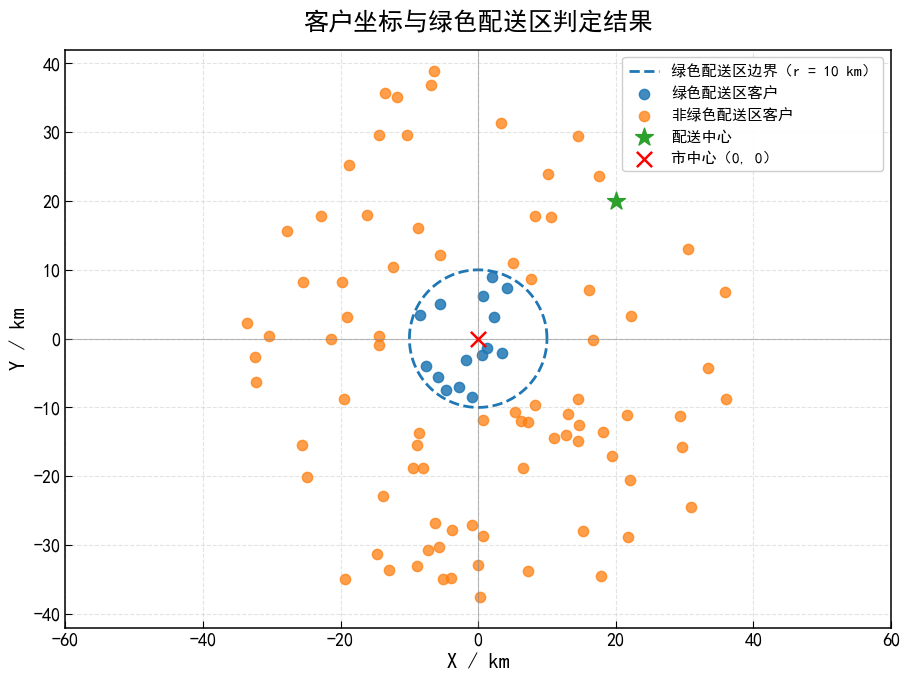


绿色配送区判定图已保存至： 处理结果\客户坐标_绿色配送区判定图.png

客户坐标信息处理结果已保存至： 处理结果\客户坐标信息_绿色配送区判定后.xlsx


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
coord_path = r"附件\客户坐标信息.xlsx"
output_dir = r"处理结果"
os.makedirs(output_dir, exist_ok=True)

coord_output_path = os.path.join(output_dir, "客户坐标信息_绿色配送区判定后.xlsx")
green_scatter_path = os.path.join(output_dir, "客户坐标_绿色配送区判定图.png")

# =========================
# 2. 读取客户坐标信息
# =========================
coord_df = pd.read_excel(coord_path)
coord_df.columns = coord_df.columns.astype(str).str.strip()

print("坐标数据维度：", coord_df.shape)
print("字段名：", list(coord_df.columns))

# =========================
# 3. 字段设置
# =========================
type_col = "类型"
id_col = "ID"
x_col = "X（km）"
y_col = "Y（km）"

# 如果你的 Excel 中字段是 X (km)、Y (km)，可以自动兼容一下
if x_col not in coord_df.columns:
    possible_x_cols = ["X (km)", "X(km)", "X", "x", "横坐标"]
    for col in possible_x_cols:
        if col in coord_df.columns:
            x_col = col
            break

if y_col not in coord_df.columns:
    possible_y_cols = ["Y (km)", "Y(km)", "Y", "y", "纵坐标"]
    for col in possible_y_cols:
        if col in coord_df.columns:
            y_col = col
            break

required_cols = [type_col, id_col, x_col, y_col]

for col in required_cols:
    if col not in coord_df.columns:
        raise ValueError(f"缺少必要字段：{col}，请检查客户坐标信息表的表头。")

print("\n实际使用字段：")
print("类型字段：", type_col)
print("ID字段：", id_col)
print("X坐标字段：", x_col)
print("Y坐标字段：", y_col)

# =========================
# 4. 数据类型转换与基础检查
# =========================
coord_df[id_col] = pd.to_numeric(coord_df[id_col], errors="coerce")
coord_df[x_col] = pd.to_numeric(coord_df[x_col], errors="coerce")
coord_df[y_col] = pd.to_numeric(coord_df[y_col], errors="coerce")

print("\n========== 坐标信息基础检查 ==========")
print("总记录数：", len(coord_df))
print("ID缺失数量：", coord_df[id_col].isna().sum())
print("X坐标缺失数量：", coord_df[x_col].isna().sum())
print("Y坐标缺失数量：", coord_df[y_col].isna().sum())
print("重复ID数量：", coord_df[id_col].duplicated().sum())

# 检查配送中心
depot_df = coord_df[coord_df[id_col] == 0]
print("\n配送中心记录数：", len(depot_df))
display(depot_df)

# =========================
# 5. 计算到市中心(0,0)的欧氏距离
# =========================
coord_df["center_distance"] = np.sqrt(coord_df[x_col] ** 2 + coord_df[y_col] ** 2)

# =========================
# 6. 判定绿色配送区
# =========================
green_radius = 10

# 只对客户点判定绿色配送区
coord_df["is_green_zone"] = (
    (coord_df[type_col] == "客户") &
    (coord_df["center_distance"] <= green_radius)
).astype(int)

# =========================
# 7. 统计绿色配送区客户
# =========================
customer_df = coord_df[coord_df[type_col] == "客户"].copy()
green_customer_df = customer_df[customer_df["is_green_zone"] == 1].copy()
non_green_customer_df = customer_df[customer_df["is_green_zone"] == 0].copy()

print("\n========== 绿色配送区判定结果 ==========")
print("客户总数：", len(customer_df))
print("绿色配送区客户数量：", len(green_customer_df))
print("非绿色配送区客户数量：", len(non_green_customer_df))

print("\n绿色配送区客户ID：")
green_ids = sorted(green_customer_df[id_col].astype(int).tolist())
print(green_ids)

# 查看绿色配送区客户详细信息
display(
    green_customer_df[[id_col, x_col, y_col, "center_distance", "is_green_zone"]]
    .sort_values(by=id_col)
    .reset_index(drop=True)
)

# =========================
# 8. 绘制客户坐标与绿色配送区示意图（保持1:1比例，横向论文版）
# =========================
fig, ax = plt.subplots(figsize=(12, 7))   # 外框更宽，更适合论文排版

# 绘制绿色配送区圆形边界
theta = np.linspace(0, 2 * np.pi, 500)
circle_x = green_radius * np.cos(theta)
circle_y = green_radius * np.sin(theta)

ax.plot(
    circle_x,
    circle_y,
    linestyle="--",
    linewidth=2.0,
    color="#1f77b4",
    label="绿色配送区边界（r = 10 km）"
)

# 绘制绿色区内客户
ax.scatter(
    green_customer_df[x_col],
    green_customer_df[y_col],
    s=55,
    alpha=0.85,
    color="#1f77b4",
    label="绿色配送区客户"
)

# 绘制绿色区外客户
ax.scatter(
    non_green_customer_df[x_col],
    non_green_customer_df[y_col],
    s=55,
    alpha=0.75,
    color="#ff7f0e",
    label="非绿色配送区客户"
)

# 绘制配送中心
if len(depot_df) > 0:
    ax.scatter(
        depot_df[x_col],
        depot_df[y_col],
        s=180,
        marker="*",
        color="#2ca02c",
        label="配送中心",
        zorder=5
    )

# 绘制市中心
ax.scatter(
    0,
    0,
    s=120,
    marker="x",
    color="red",
    linewidths=1.8,
    label="市中心（0, 0）",
    zorder=6
)

# 坐标轴标签与标题
ax.set_xlabel("X / km", fontsize=15)
ax.set_ylabel("Y / km", fontsize=15)
ax.set_title("客户坐标与绿色配送区判定结果", fontsize=18, pad=14)

# 坐标辅助线
ax.axhline(0, linewidth=0.8, color="gray", alpha=0.5)
ax.axvline(0, linewidth=0.8, color="gray", alpha=0.5)

# 网格
ax.grid(True, linestyle="--", alpha=0.35)

# -------------------------
# 关键：手动扩展 x 轴范围，但保持 1:1 比例
# -------------------------
ax.set_xlim(-60, 60)   # x轴范围扩大
ax.set_ylim(-42, 42)   # y轴范围保持与数据接近

# 保持图中几何比例为 1:1
ax.set_aspect("equal", adjustable="box")

# 图例
ax.legend(
    loc="upper right",
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)

# 刻度字号
ax.tick_params(axis="both", labelsize=13)

plt.tight_layout()
plt.savefig(green_scatter_path, dpi=400, bbox_inches="tight")
plt.show()

print("\n绿色配送区判定图已保存至：", green_scatter_path)

# =========================
# 9. 保存处理后的客户坐标信息
# =========================
coord_df.to_excel(coord_output_path, index=False)

print("\n客户坐标信息处理结果已保存至：", coord_output_path)